In [52]:
%pip install pandas numpy seaborn matplotlib statsmodels

In [53]:
import pandas as pd
import re
import enum
import os

class Models(enum.Enum):
    MIXTRAL8_7 = "mixtral-8x7b-32768"
    MIXTRAL8_22 = 'mixtral-8x22b-65536'
    LLAMA3 = "llama3-70b-8192"
    GPT3_5 = "gpt-3.5-turbo"
    GPT4 = "gpt-4-turbo"
    GPT4o = "gpt-4o"

model_renames = {
    "mixtral-8x7b-32768": "mixtral-8x7b",
    "mixtral-8x22b-65536": "mixtral-8x22b",
    "llama3-70b-8192": "llama-3-70b",
    "llama-3-70b-8192": "llama-3-70b",
}

In [54]:
CWE_LIST = ["CWE-22", "CWE-89", "CWE-79"]

MODELS = [Models.MIXTRAL8_7, Models.MIXTRAL8_22, Models.LLAMA3, Models.GPT3_5, Models.GPT4o, Models.GPT4]
# MODELS = [Models.MIXTRAL8_7,  Models.GPT3_5]
# MODELS = [ Models.MIXTRAL8_7]
# MODELS = [Models.LLAMA3]

BUGGY_FILES_FOLDER = "./source_files"
MAX_CHARS = 250001

# Setup

## Definition of files

In [55]:
files_dict = {
    406: {
        "main_padding": "/php/406/406_modifiedFile.php",
        "buggy_content": "/php/406/406_smallestBuggy.php",
        "buggy_line": "$selectedIds = explode(',', $selectedIds);",
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    408: {
        'main_padding': '/php/408/408_modifiedFile.php',
        "additional_padding": ["/php/408/additional_padding.php"],
        "buggy_content": "/php/408/408_smallestBuggy.php",
        "buggy_line": '''SELECT * FROM ' . static::table_name() . ' WHERE ' . $property .  ''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    405: {
        'main_padding': '/php/405/405_modifiedFile.php',
        "additional_padding": ["/php/405/additional_padding.php"],
        "buggy_content": "/php/405/405_smallestBuggy.php",
        "buggy_line": '''$where = "WHERE group_ID = {$group_id}";''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4921: {
        'main_padding': '/go/4921/4921_modifiedFile.go',
        "additional_padding": ["/go/4921/additional_padding.go"],
        "buggy_content": "/go/4921/4921_smallestBuggy.go",
        "buggy_line": '''order := fmt.Sprintf("`%s` %s", DefaultQuery(c, "sort_by", "id"), sort)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    4928: {
        'main_padding': '/php/4928/4928_modifiedFile.php',
        "additional_padding": ["/php/4928/additional_padding.php"],
        "buggy_content": "/php/4928/4928_smallestBuggy.php",
        "buggy_line": '''return @mysqli_real_escape_string($fmdb->dbh, $data);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-89"
    },
    3989:{
        'main_padding': '/js/3989/3989_modifiedFile.js',
        "additional_padding": ["/js/3989/additional_padding.js"],
        "buggy_content": "/js/3989/3989_smallestBuggy.js",
        "buggy_line": '''`window[${idJSON}].push(${serializedCacheArgs});`,''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3976:{
        'main_padding': '/js/3976/3976_modifiedFile.js',
        "additional_padding": ["/js/3976/additional_padding.js"],
        "buggy_content": "/js/3976/3976_smallestBuggy.js",
        "buggy_line": '''const header = container.querySelector(`h${level}`);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    3968:{
        'main_padding': '/php/3968/3968_modifiedFile.php',
        "additional_padding": ["/php/3968/additional_padding.php"],
        "buggy_content": "/php/3968/3968_smallestBuggy.php",
        "buggy_line": '''$response['data']['path'] = $model->path;''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    300:{
        'main_padding': '/php/300/300_modifiedFile.php',
        "additional_padding": ["/php/300/additional_padding.php"],
        "buggy_content": "/php/300/300_smallestBuggy.php",
        "buggy_line": '''<td>' . $item->id . '</td>''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-79"
    },
    302:{
        'main_padding': '/rb/302/302_modifiedFile.rb',
        "additional_padding": ["/rb/302/additional_padding.rb"],
        "buggy_content": "/rb/302/302_smallestBuggy.rb",
        "buggy_line": '''@filter = params[:filter] || "*"''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-79"
    },
    5422:{
        'main_padding': '/go/5422/5422_modifiedFile.go',
        "additional_padding": ["/go/5422/additional_padding.go"],
        "buggy_content": "/go/5422/5422_smallestBuggy.go",
        "buggy_line": '''outdir := filepath.Join(basePath, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5396:{
        'main_padding': '/java/5396/5396_modifiedFile.java',
        "additional_padding": ["/java/5396/additional_padding.java"],
        "buggy_content": "/java/5396/5396_smallestBuggy.java",
        "buggy_line": '''URI uri = toURI(fileUri);''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5404:{
        'main_padding': '/go/5404/5404_modifiedFile.go',
        "additional_padding": ["/go/5404/additional_padding.go"],
        "buggy_content": "/go/5404/5404_smallestBuggy.go",
        "buggy_line": '''target := filepath.Join(dst, name)''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    5414:{
        'main_padding': '/js/5414/5414_modifiedFile.js',
        "additional_padding": ["/js/5414/additional_padding.js"],
        "buggy_content": "/js/5414/5414_smallestBuggy.js",
        "buggy_line": '''var filename = path.join(__dirname, "public", req.url.path_list.join("/"));''',
        "split_string": "// -x-",
        "CWE_ID": "CWE-22"
    },
    493:{
        'main_padding': '/py/493/493_modifiedFile.py',
        "additional_padding": ["/py/493/additional_padding.py"],
        "buggy_content": "/py/493/493_smallestBuggy.py",
        "buggy_line": '''return FileResponse(f"user_images/pfp/{username}", media_type='image/gif')''',
        "split_string": "# -x-",
        "CWE_ID": "CWE-22"
    },
}

## Import CSV

In [56]:
def import_csv(cwe_list, models, files_path, inference_results_folder):
    df_files = pd.read_csv(files_path)
    #df_files = df_files[df_files['target_length'] <= MAX_CHARS]

    combined_df = pd.DataFrame()

    for model in models:
        df_model = pd.read_csv(inference_results_folder+"/"+model.value+".csv")
        for cwe_id in cwe_list:

            # print(f"Processing CWE {cwe_id} for model {model}")
            df_cwe = df_files[(df_files['CWE_ID'] == cwe_id)]

            if len(df_cwe) == 0:
                # print(f"No files found for CWE {cwe_id}")
                continue

            df_combined = pd.merge(df_model, df_cwe, on='file_id', how='inner')

            _check_files(df_model, df_cwe)


            combined_df = pd.concat([combined_df, df_combined])

    combined_df = combined_df[['content', 'model_output', 'prompt', 'file_id', 'database_file_id', 'length', 'bug_position', 'target_bug_position', 'target_length', 'CWE_ID', 'model']]
    
    return combined_df

# Check files function
def _check_files(df_data, df_files):
    file_ids_data = df_data['file_id'].value_counts()
    file_ids_files = df_files['file_id'].unique()

    problems = []
    for file_id in file_ids_files:
        if file_id not in file_ids_data or file_ids_data[file_id] != 1:
            problems.append(file_id)
        
    # if len(df_data) != len(df_files):
        # print(f"Data count mismatch: Expected {len(df_files)}, got {len(df_data)}.")

    # if problems:
    #     print(f"Some file_ids are missing the required number of entries in the data:")
    #     for file_id in problems:
    #         count = file_ids_data[file_id] if file_id in file_ids_data else 0
    # else:
    #     print("All file_ids have the correct number of entries.")


## Extracting functions for classification

In [57]:
def extract_code_or_return_original(text):
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        return text

    results = []
    for match in matches:
        results.append(match.group(2).strip())

    return "\n".join(results)

def clean_whitespace(text):
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    bug_line = extract_code_or_return_original(bug_line).strip()

    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
    bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)

    _has_bug_line = bool(bug_line_pattern.search(model_output))

    if not _has_bug_line:
        return False
    
    bug_line = extract_bug_line(model_output)
    bug_line = remove_spaces(clean_whitespace(bug_line)).strip()

    if(len(bug_line) == 0):
        return False

    if(_has_bug_line and ('BL: None'.lower() not in model_output.lower() or "BUG FOUND: NO".lower() not in model_output.lower())):
        return True
    
    if code and code != model_output:
        return True

# Clean patch function
def clean_patch(patch):
    return re.sub(r'^[+-]', '', patch, flags=re.MULTILINE)

In [58]:
def load_buggy_file(filepath):
    with open(BUGGY_FILES_FOLDER+filepath, 'r') as file:
        return file.read()

In [59]:
def classify(record, file_dict):
    model_output = record['model_output']

    classification = None
    bug_line = None
    bug_line_in_content = False

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    # Check for matches
    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    # stronger conditions -> lets rely purely on model_output under Bug found
    if type == 'not_buggy':
        if has_bug_true_indication: 
            classification = 'FP'
        else:
            classification = 'TN'
    elif type == 'buggy' and has_bug_false_indication: 
        classification = 'FN'
    else:
        # weaker decision based in bugged_line
        if not _has_bug_line:
            classification = 'FN'
        else:
            bug_line = remove_spaces(extract_bug_line(model_output))
            # patch_removal = remove_spaces(clean_whitespace(get_removed_lines(patch)))
            cleaned_patch = remove_spaces(clean_whitespace(clean_patch(load_buggy_file(file_dict[record['database_file_id']]['buggy_content']))))

            bug_line_in_patch = bug_line in cleaned_patch

            if (len(bug_line) > 0 and bug_line_in_patch):
                classification = 'TP'
            else:
                classification = 'FN' 
        
    return pd.Series([classification, bug_line])

# Prepare dataframe function
def prepare_df(df, file_dict):
    df[['classification', 'bug_line']] = df.apply(lambda record: classify(record, file_dict), axis=1)
    return df

# Heatmap plotting

In [60]:
runs = {
    'run1': {
        'files': './files.csv',
        'inference': './runs/run1/inference'
    },
    'run2': {
        'files': './files.csv',
        'inference': './runs/run2/inference'
    },
    'run3': {
        'files': './files.csv',
        'inference': './runs/run3/inference'
    },
    'run4': {
        'files': './files.csv',
        'inference': './runs/run4/inference'
    },
    'run5': {
        'files': './files.csv',
        'inference': './runs/run5/inference'
    }
    
}
df_total = pd.DataFrame()
for run in runs:
    files_path = runs[run]['files']
    inference_results_folder = runs[run]['inference']
    try:
        combined_df = import_csv(CWE_LIST, MODELS, files_path, inference_results_folder)
        df = prepare_df(combined_df, files_dict)
        # add run column
        df['run'] = run
        df_total = pd.concat([df_total, df])
    except:
        pass
df = df_total


# previous preparation 
# combined_df = import_csv(CWE_LIST, MODELS)
# df = prepare_df(combined_df, files_dict)

In [61]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

fontsize = 14

def create_classification_matrix(df):
    classification_mapping = {'TP': 1, 'FP': -1, 'TN': 0, 'FN': -1}
    # Create mappings based on unique entries in 'target_bug_position' and 'target_length'
    bug_pos_mapping = {val: idx for idx, val in enumerate(sorted(df['target_bug_position'].unique()))}
    file_char_mapping = {val: idx for idx, val in enumerate(sorted(df['target_length'].unique()))}
    
    # Initialize the matrix and count matrix
    matrix = np.zeros((len(file_char_mapping), len(bug_pos_mapping)))
    count_matrix = np.zeros((len(file_char_mapping), len(bug_pos_mapping)))

    # Populate matrix and count matrix
    for _, row in df.iterrows():
        file_idx = file_char_mapping[row['target_length']]
        bug_idx = bug_pos_mapping[row['target_bug_position']]
        classification_value = classification_mapping[row['classification']]
        matrix[file_idx][bug_idx] += classification_value
        count_matrix[file_idx][bug_idx] += 1

    # Calculate averages and prepare annotations
    annotations = np.zeros_like(matrix, dtype=object)
    for i in range(len(file_char_mapping)):
        for j in range(len(bug_pos_mapping)):
            if count_matrix[i][j] > 0:
                avg_value = matrix[i][j] / count_matrix[i][j]
                matrix[i][j] = avg_value
                #annotations[i][j] = f"{avg_value:.1f}"
                annotations[i][j] = ""
            else:
                annotations[i][j] = ""

    return matrix, list(bug_pos_mapping.keys()), list(file_char_mapping.keys()), annotations

def plot_heatmap(gs, matrix, x_labels, y_labels, annotations, cmap, norm, name, grid_position, first_row, first_col, last_row, last_col):
    ax = plt.subplot(gs[grid_position])
    sns.heatmap(matrix, annot=annotations, fmt="", cbar=last_col, cmap=cmap, norm=norm, 
                xticklabels=x_labels if last_row else [], 
                yticklabels=y_labels if first_col else [], 
                annot_kws={"size": fontsize}, ax=ax)  # Increase annotation font size for better readability
    
    if last_row:
        #x_labels = x_labels + [x_labels[-1]+500]
        # Define tick positions and labels to display every second label
        tick_positions = range(0, matrix.shape[1], 2)  # positions for every second column
        tick_labels = x_labels[::2]  # every second label from the x_labels list
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)


    ax.tick_params(axis='x', labelsize=10)  # Increase x-tick font size
    ax.tick_params(axis='y', labelsize=10)  # Increase y-tick font size

    if first_row:
        if isinstance(name, (list, tuple)) and len(name) > 1:
            ax.set_title(name[1], fontsize=fontsize)
        else:
            ax.set_title(name, fontsize=fontsize)
    if first_col:
        ax.set_ylabel(f'{name[0] if isinstance(name, (list, tuple)) else name}\nFile Size', fontsize=fontsize)
    if last_row:
        ax.set_xlabel('Bug Position', fontsize=fontsize)

def generate_heatmaps(data, group_by, save_path='./', filename='heatmap_grid'):
    if not isinstance(group_by,(list,tuple)):
        group_by = [group_by]
        
    # Renaming models
    data['model'] = data['model'].replace(model_renames)
    # Set the order for the CWE_ID column if it's in the group_by
    if 'CWE_ID' in group_by:
        cwe_order = ["CWE-22", "CWE-89", "CWE-79"]  # This is the specific order you want
        data['CWE_ID'] = pd.Categorical(data['CWE_ID'], categories=cwe_order, ordered=True)
        data.sort_values(by=group_by, inplace=True)  # Sort by group_by columns including 'CWE_ID'

    colors = ["red", "white", "green"]
    nodes = [0.0, 0.5, 1.0]
    cmap = mcolors.LinearSegmentedColormap.from_list("", list(zip(nodes, colors)))
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    groups = data.groupby(group_by)
    num_groups = len(groups)
    grid_rows = len(data[group_by[0]].unique())
    grid_cols = len(data[group_by[1]].unique()) if len(group_by) > 1 else 1

    plt.figure(figsize=(grid_cols * 8, grid_rows * 2.5))
    gs = gridspec.GridSpec(grid_rows, grid_cols)

    for idx, (name, group) in enumerate(groups):
        matrix, x_labels, y_labels, annotations = create_classification_matrix(group)
        plot_heatmap(gs, matrix, x_labels, y_labels, annotations, cmap, norm, name, idx, 
                     idx < grid_cols, idx % grid_cols == 0, idx//grid_cols == grid_rows-1, (idx+1) % grid_cols == 0)

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"{filename}.pdf"))
    plt.show()

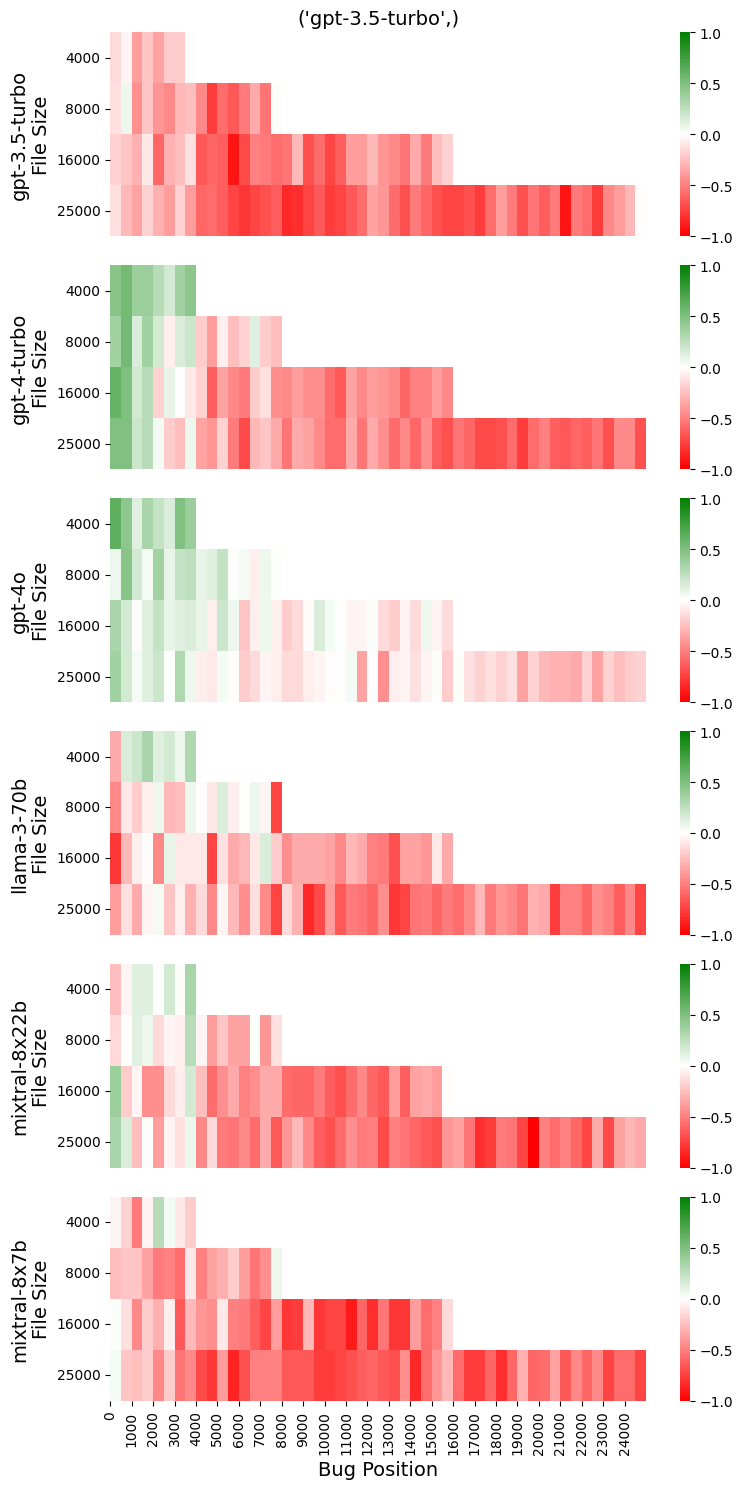

C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(group_by)


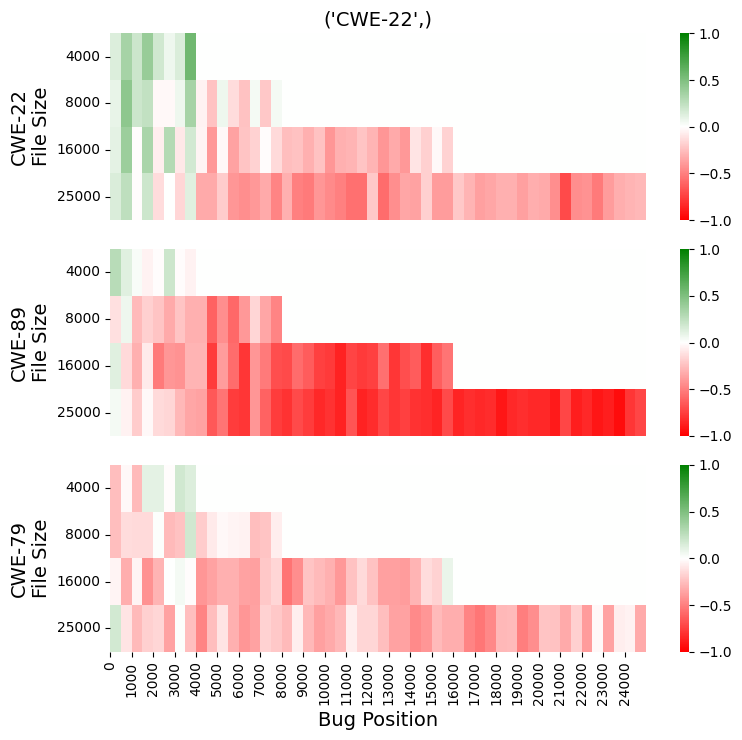

C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(group_by)


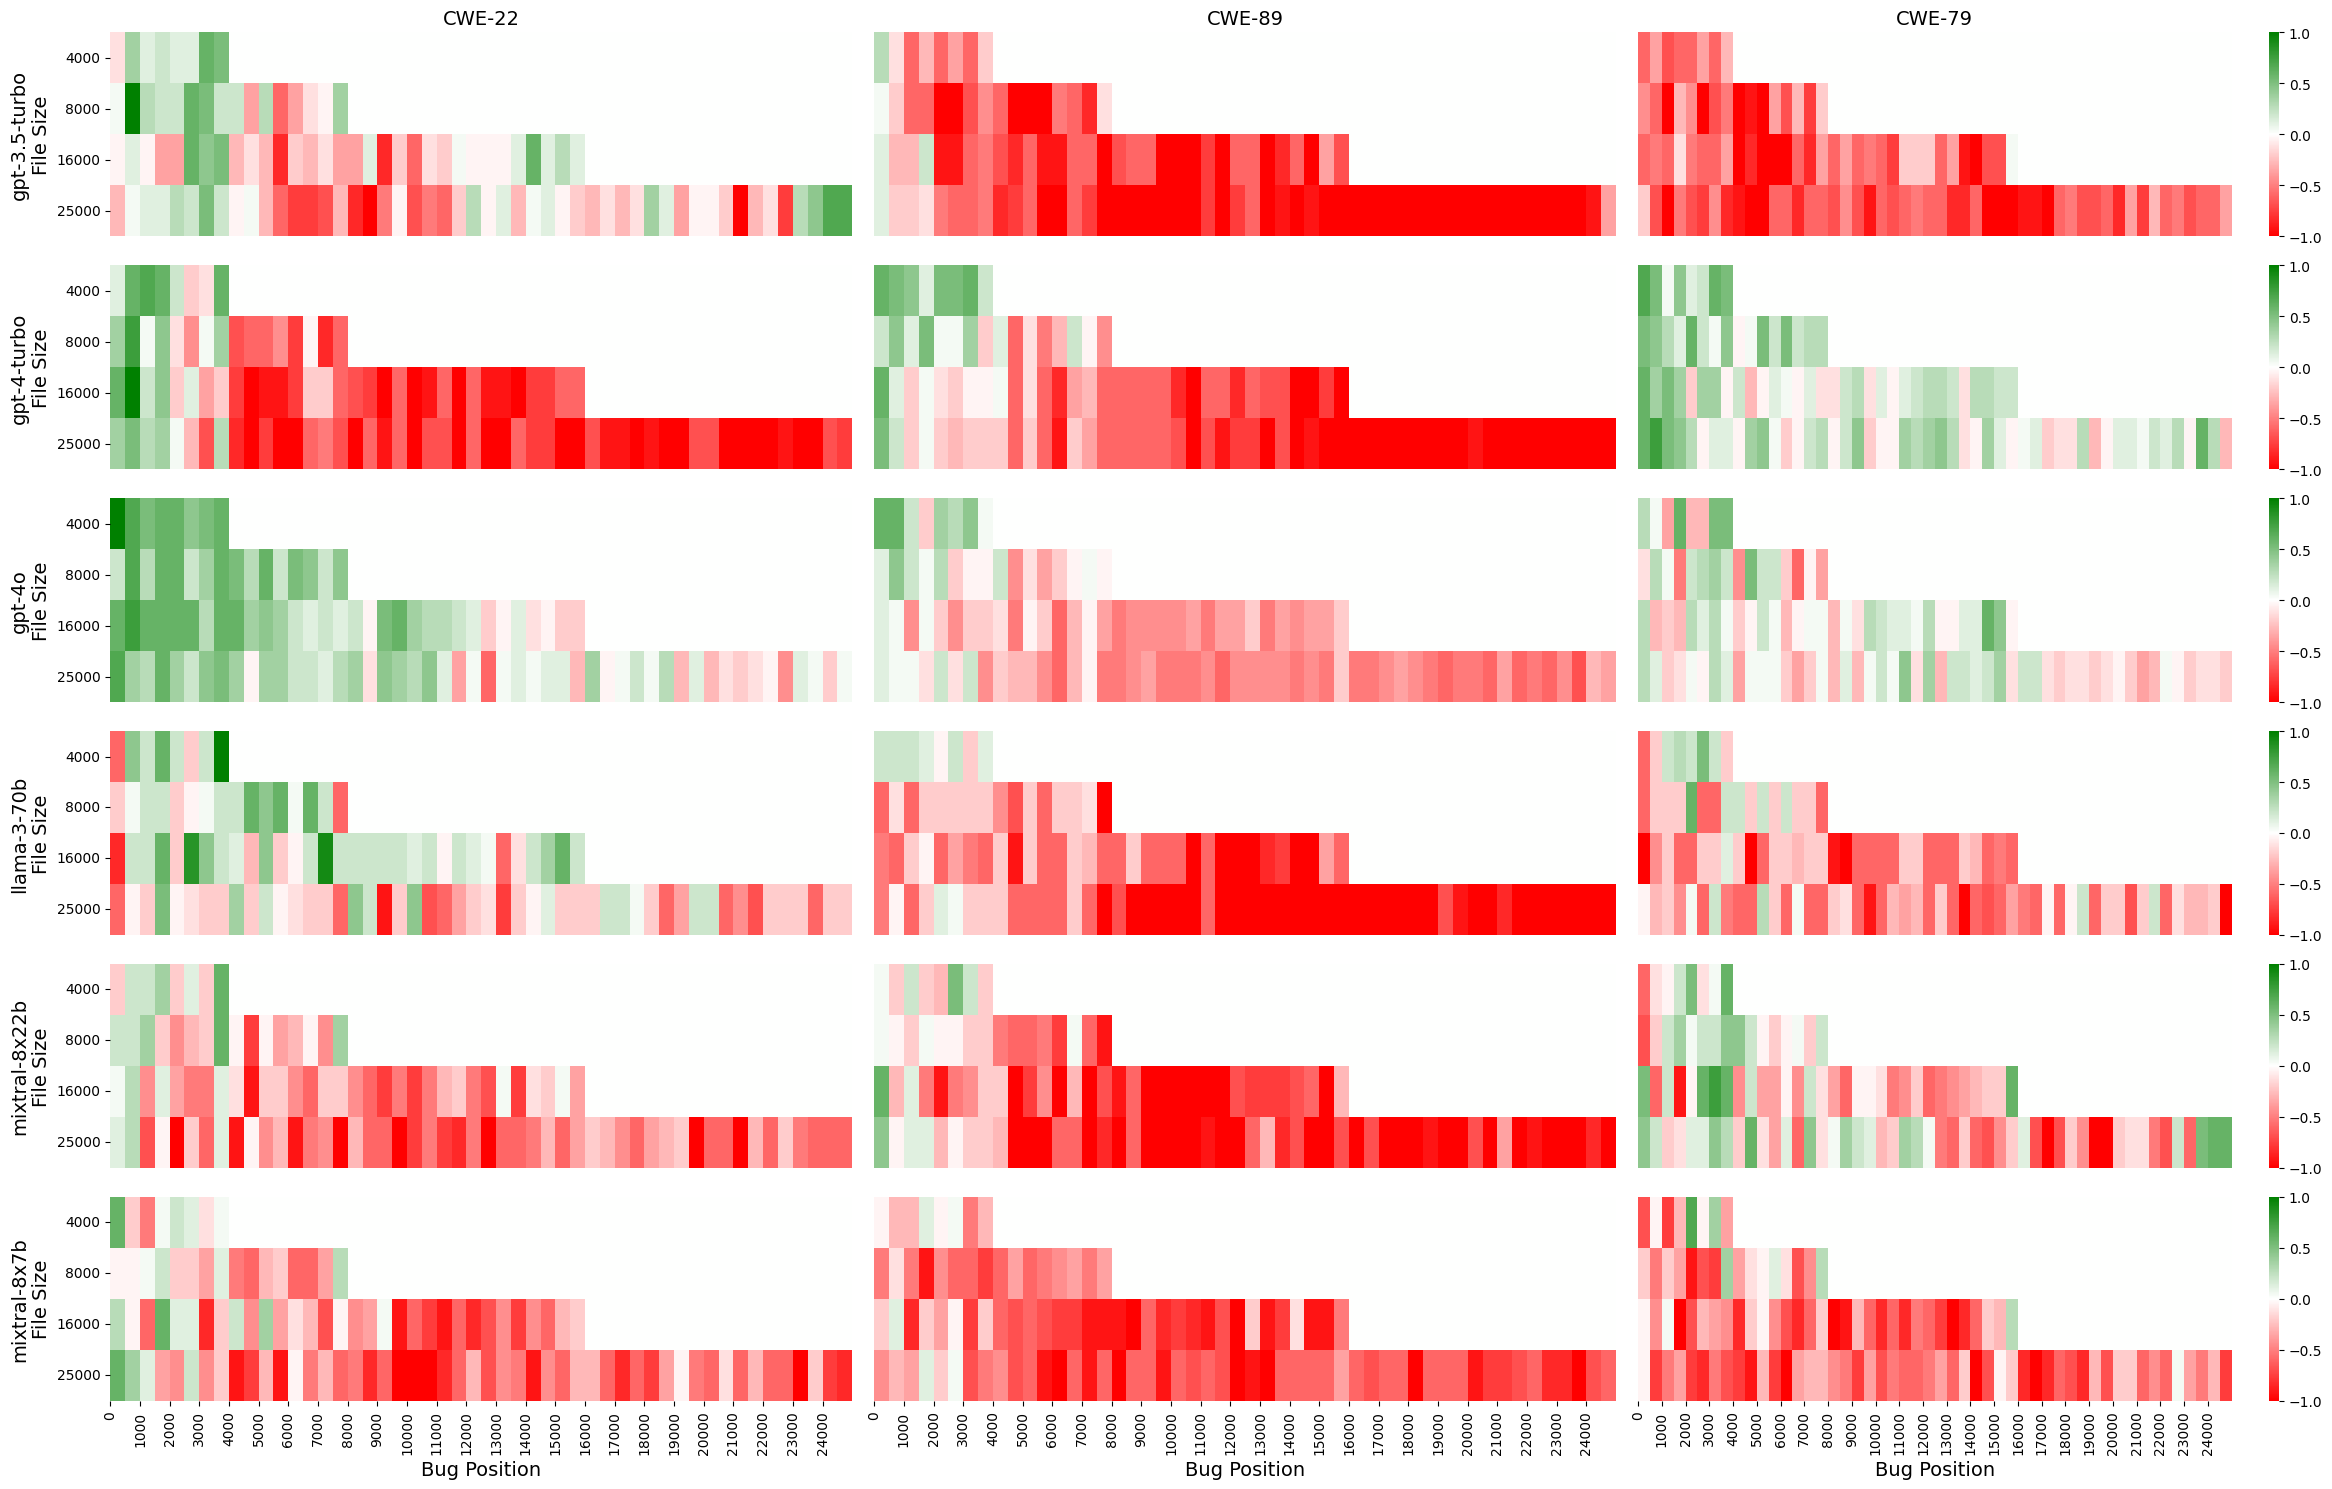

In [62]:
# To display overview of all files aggregated per model
generate_heatmaps(
    data= df, 
    group_by= ['model'], 
    filename= 'heatmap_grid_model'
)

# To display overview of all files aggregated per CWE -> simple comparision across models
# generate_heatmaps(df[df['CWE_ID']=='CWE-89'], 'model', filename= 'heatmap_grid_cwe89')

# To display overall CWE results
generate_heatmaps(
    data= df, 
    group_by= ['CWE_ID'], 
    filename= 'heatmap_grid_cwe'
)

# To display results per model per CWE
generate_heatmaps(
    data= df, 
    group_by= ['model','CWE_ID'],
    filename= 'heatmap_grid_all'
)


# Accumulation across runs

C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['model'] = data['model'].replace(model_renames)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CWE_ID'] = pd.Categorical(data['CWE_ID'], categories=cwe_order, ordered=True)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

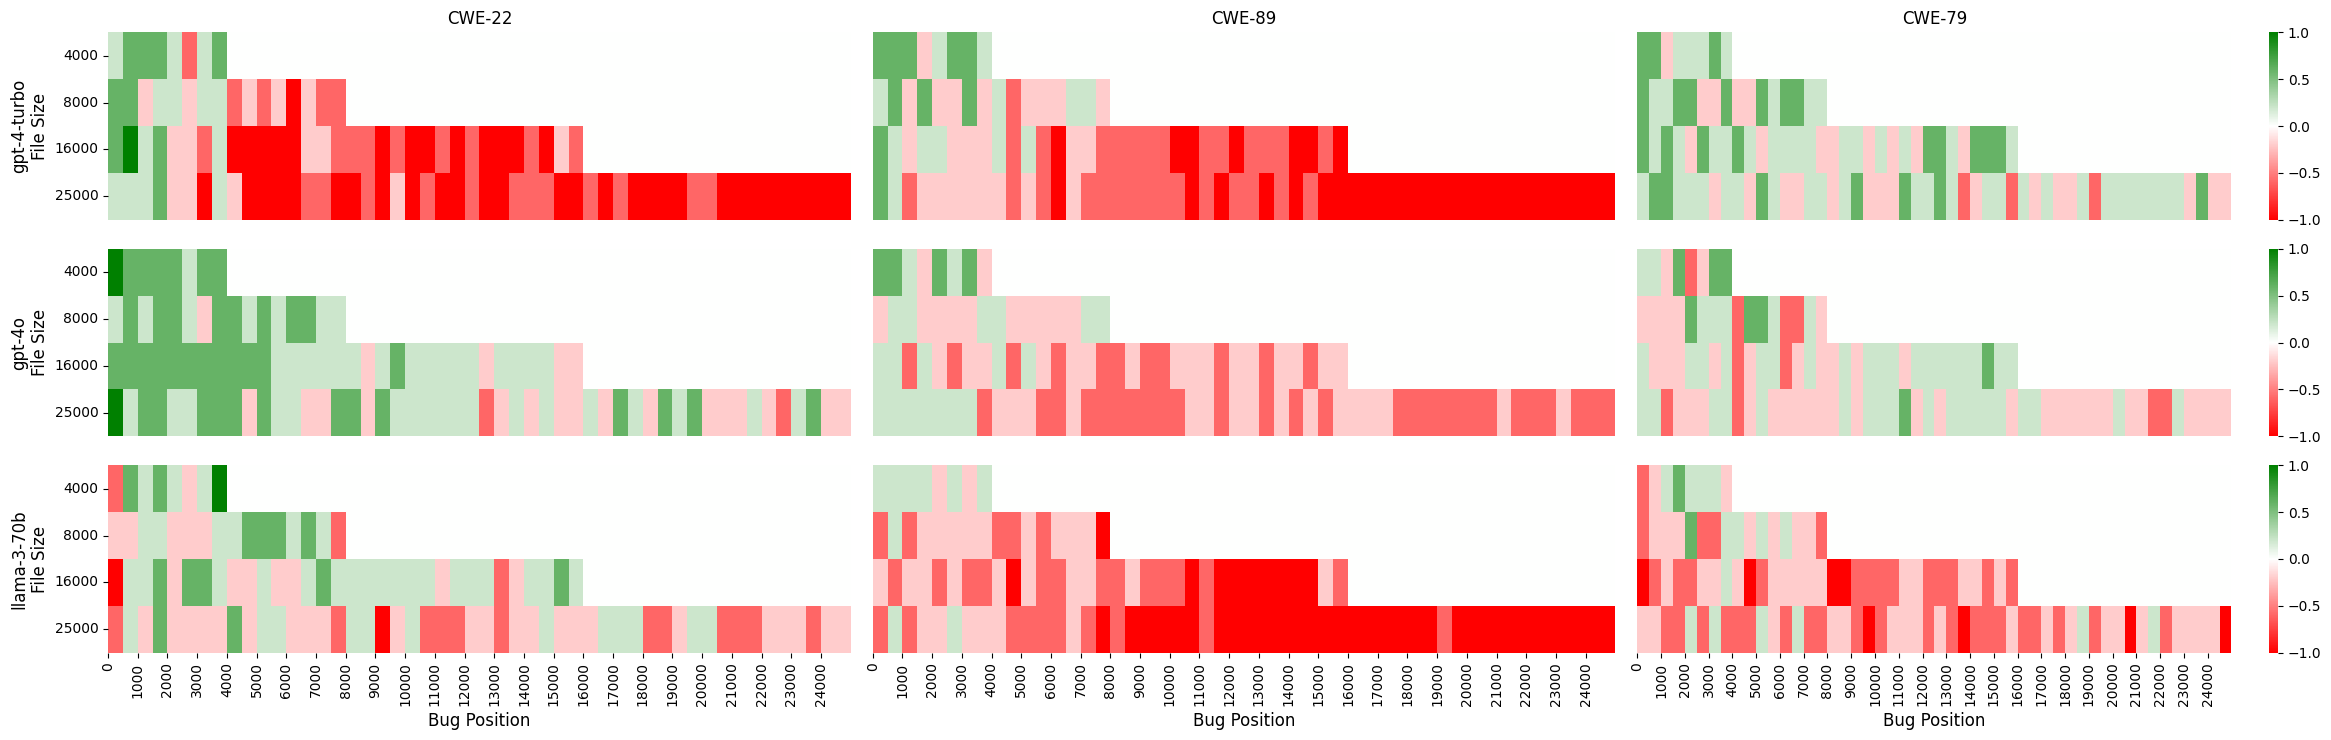

C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['model'] = data['model'].replace(model_renames)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CWE_ID'] = pd.Categorical(data['CWE_ID'], categories=cwe_order, ordered=True)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

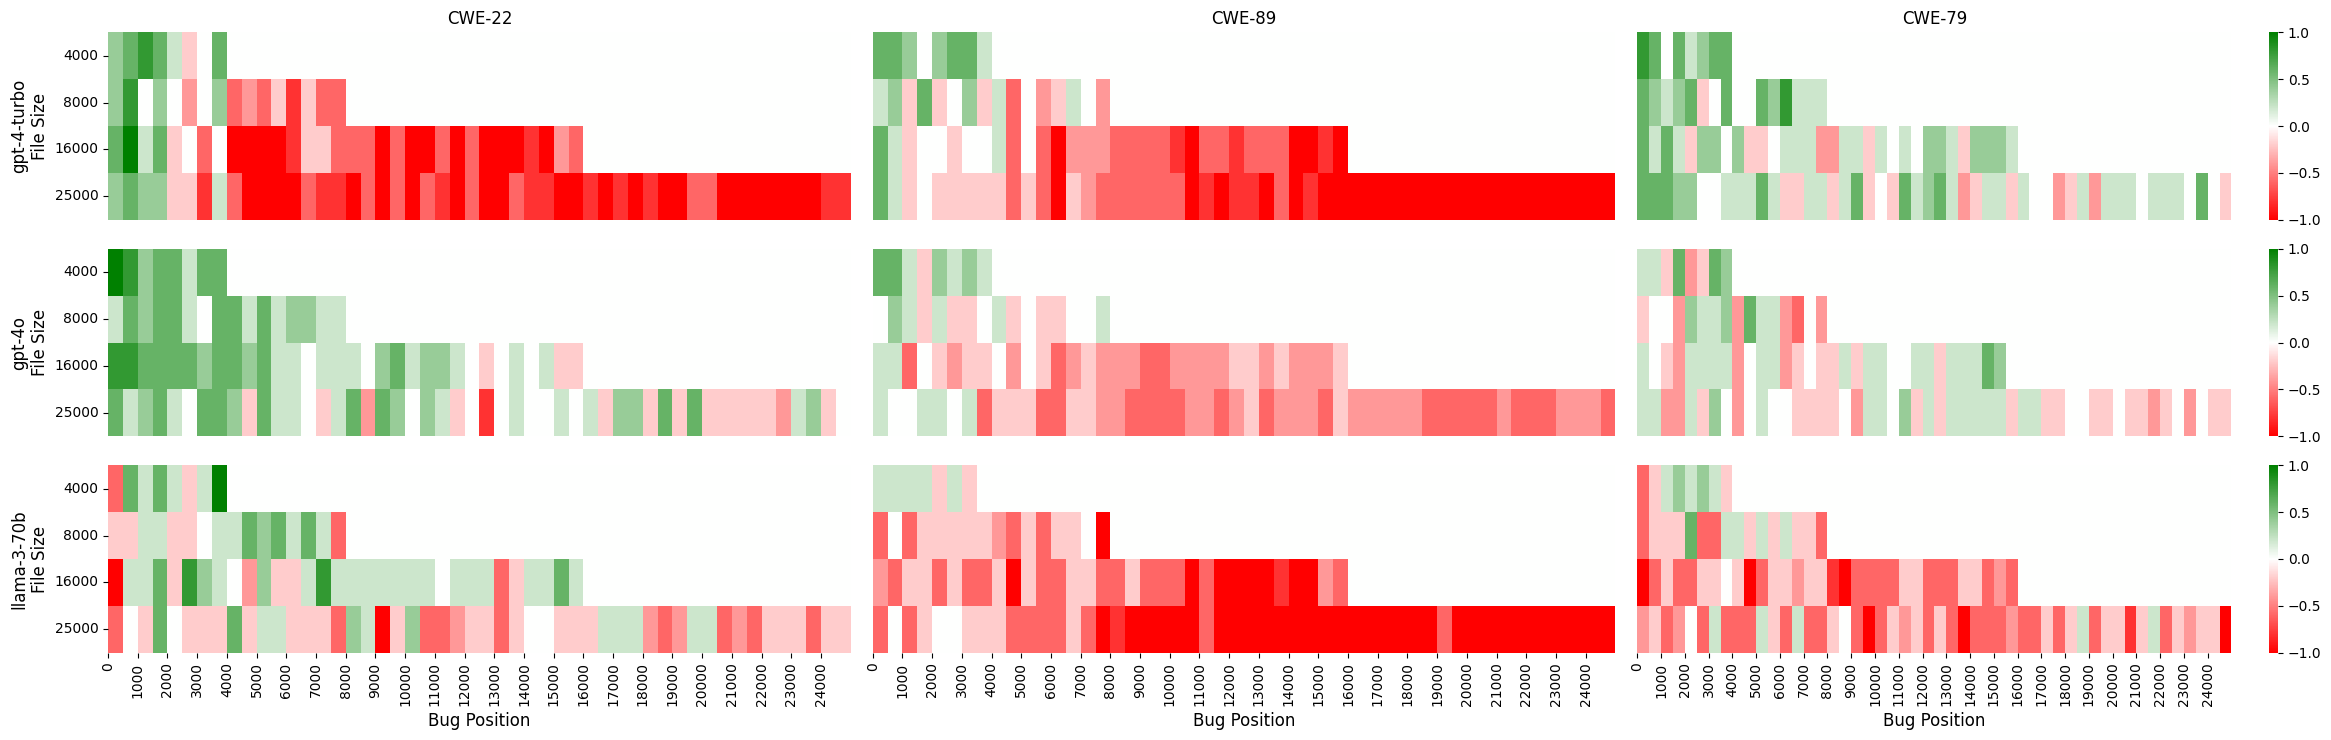

C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['model'] = data['model'].replace(model_renames)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CWE_ID'] = pd.Categorical(data['CWE_ID'], categories=cwe_order, ordered=True)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

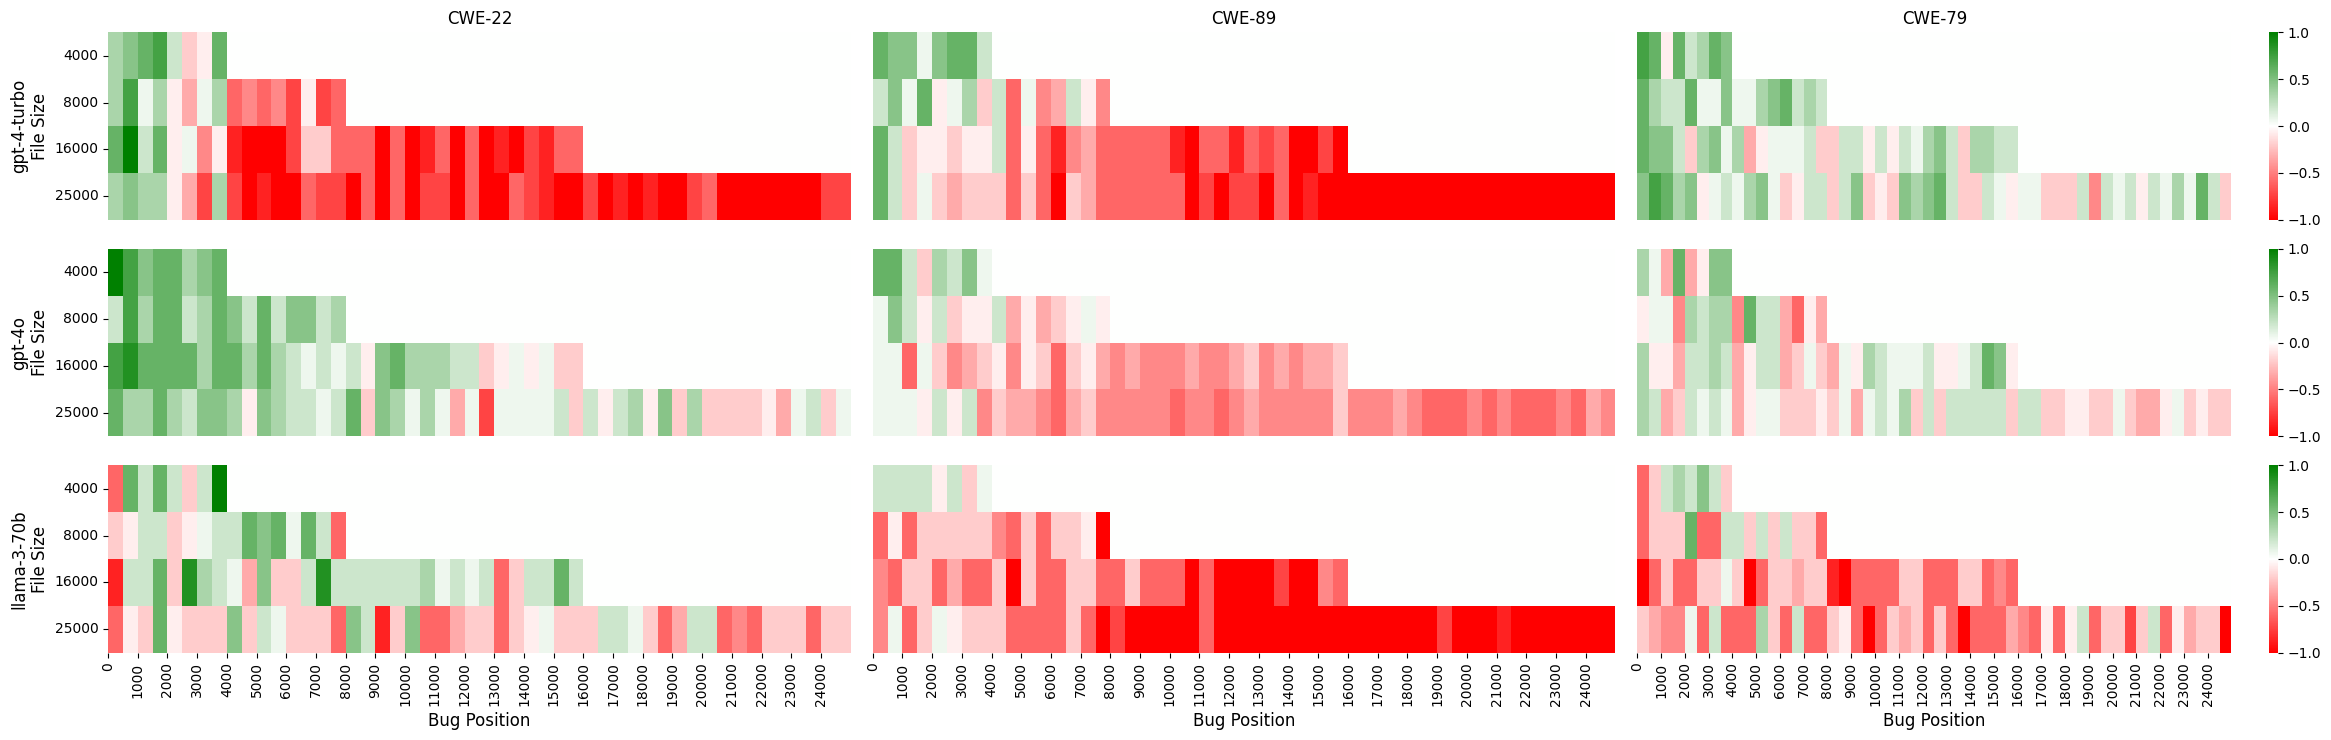

C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['model'] = data['model'].replace(model_renames)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CWE_ID'] = pd.Categorical(data['CWE_ID'], categories=cwe_order, ordered=True)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

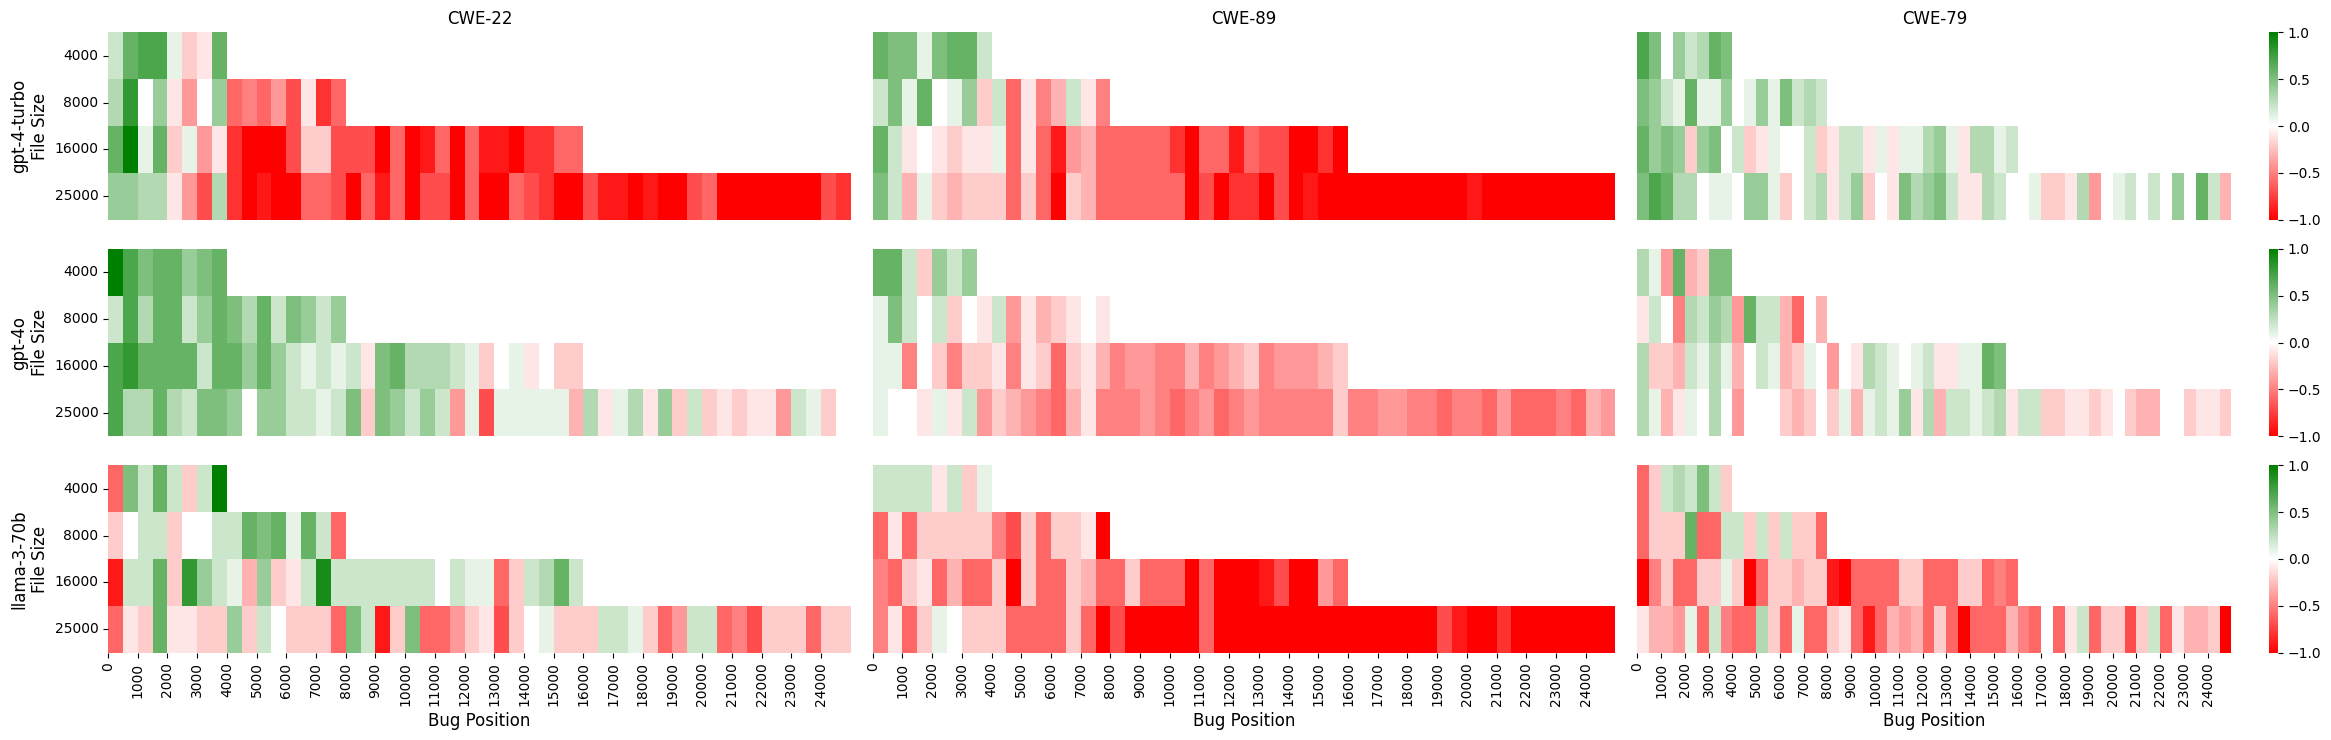

C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['model'] = data['model'].replace(model_renames)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CWE_ID'] = pd.Categorical(data['CWE_ID'], categories=cwe_order, ordered=True)
C:\Users\adam\AppData\Local\Temp\ipykernel_13744\863613267.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

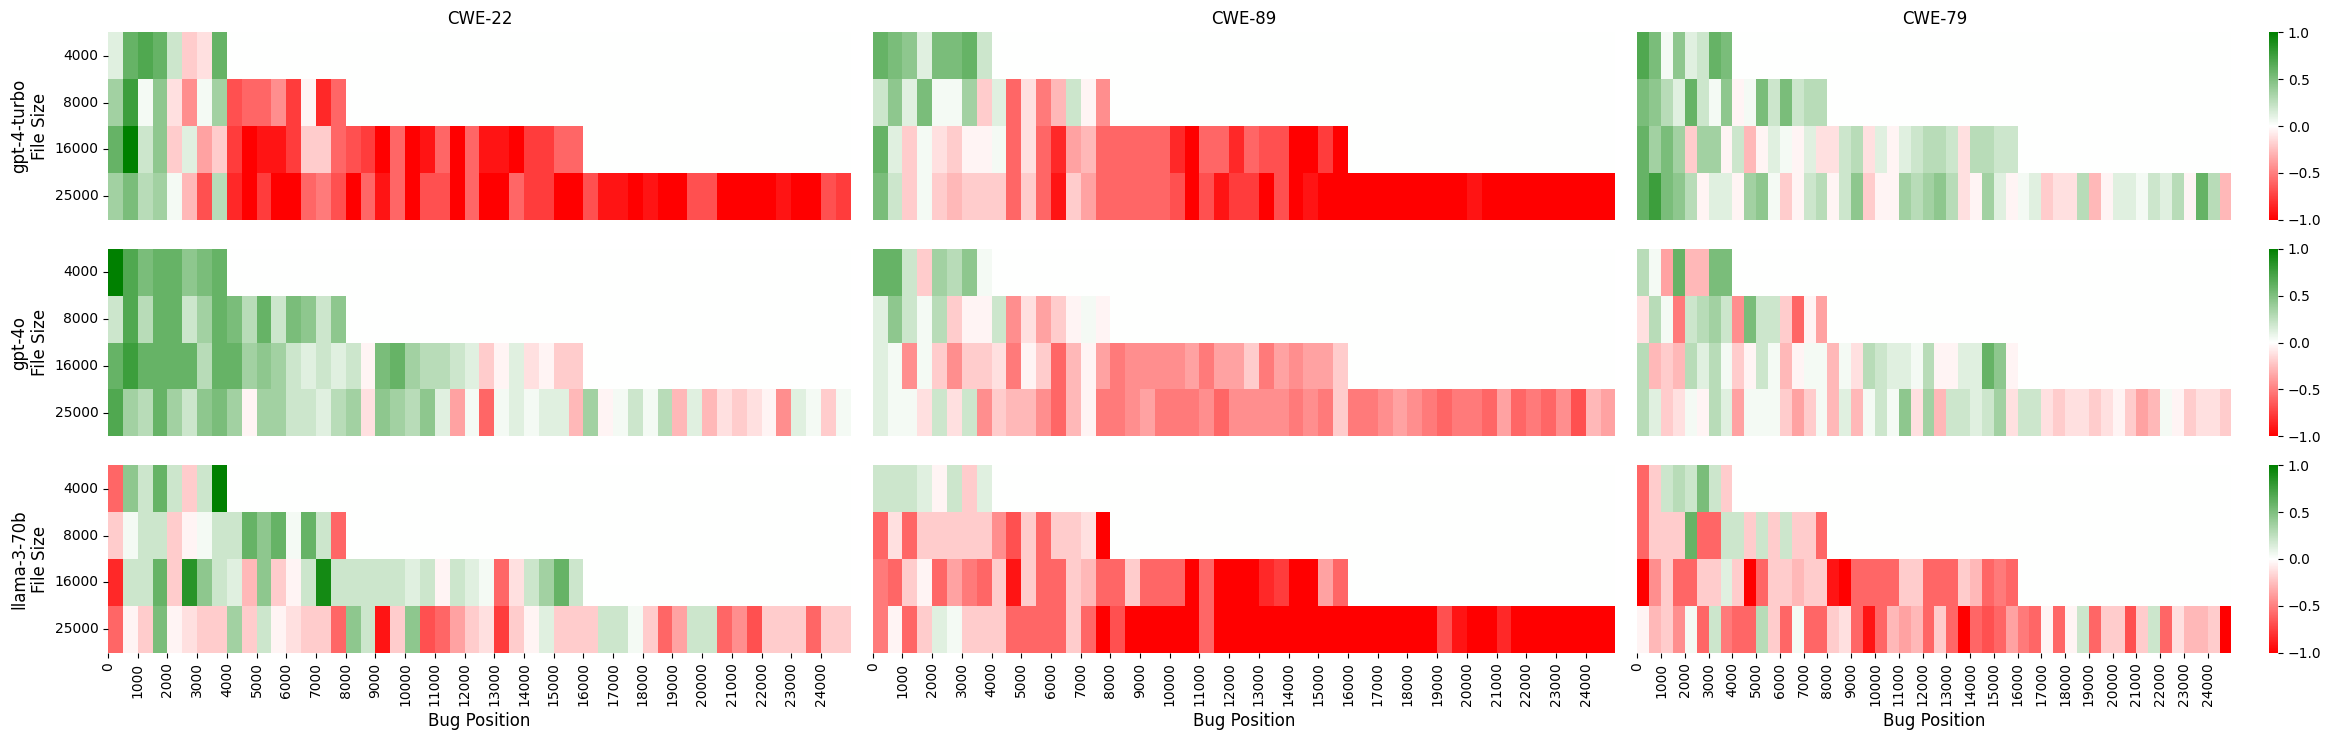

In [69]:
accumulated_df = pd.DataFrame()
for i, run in enumerate(runs):
    run_df = df_total[df_total['run'] == run]
    accumulated_df = pd.concat([accumulated_df, run_df])
    
    filtered_df = accumulated_df[(accumulated_df['model'] == Models.LLAMA3.value) | 
                                 (accumulated_df['model'] == Models.GPT4o.value) | 
                                 (accumulated_df['model'] == Models.GPT4.value)]
    
    generate_heatmaps(
        data=filtered_df,
        group_by=['model', 'CWE_ID'],
        filename=f'heatmap_grid_llama+gpt4_run{i+1}'
    )

# Logistic Regression

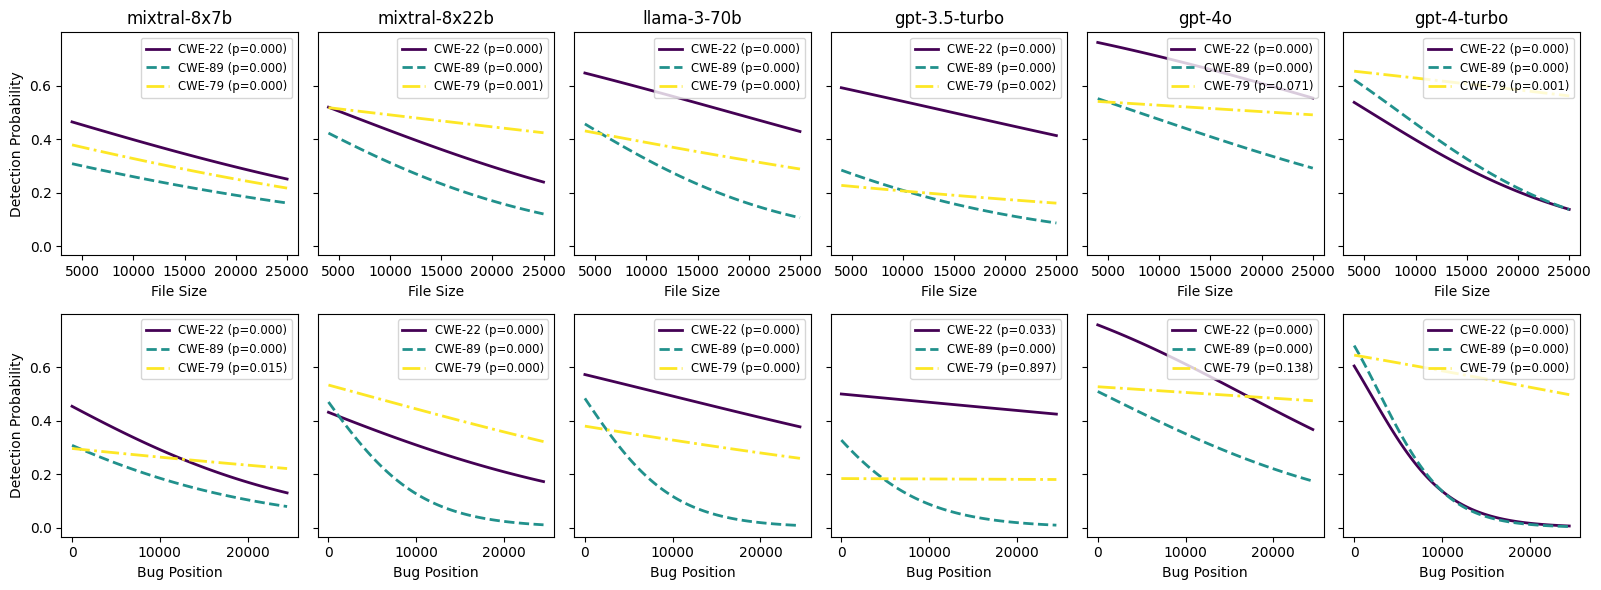

In [65]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Logistic Regression Plotting Functions
def plot_logistic_regressions_for_all_models(df, models, features, cwe_ids, save_path='./'):
    # Prepare the classification column for logistic regression
    df = df[df['classification'].isin(['TP', 'FN'])]
    df['classification_TP'] = df['classification'].apply(lambda x: 1 if x == 'TP' else 0)

    fig, axes = plt.subplots(nrows=len(features), ncols=len(models), figsize=(8 * len(features), len(models)), dpi=100, sharex='row', sharey='all')
    fig.subplots_adjust(hspace=0.4, wspace=0.3)  # Adjust spacing between plots
    colors = plt.cm.viridis(np.linspace(0, 1, len(cwe_ids)))  # Generate a color array

    for row, feature in enumerate(features):
        for col, model in enumerate(models):
            ax = axes[row, col] if len(features) > 1 else axes
            for cwe_id, color in zip(cwe_ids, colors):
                cwe_df = df[(df['CWE_ID'] == cwe_id) & (df['model'] == model.value)]
                if not cwe_df.empty:
                    plot_logistic_regression(cwe_df, feature, 'classification_TP', cwe_id, ax, color)
            feature_label = 'Bug Position' if feature=='target_bug_position' else 'File Size'
            if col == 0:  # Set Y-axis labels for the first column only
                ax.set_ylabel("Detection Probability")
            ax.set_xlabel(feature_label)
            ax.legend(loc='upper right', fontsize='small')

            # Optionally set titles for the first row, or adjust according to your needs
            if row == 0:
                # Renaming models
                ax.set_title(model_renames.get(model.value,model.value))

    #fig.suptitle(f'Logistic Regression Analysis Across CWEs for All Models', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path,"logistic_regression_all_models_heatmap.pdf"))
    plt.show()

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    model = sm.Logit(y, X).fit(disp=0)
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    y_probs = model.predict(sm.add_constant(x_values))
    
    label_dict = {
        "CWE-22": "CWE-22",
        "CWE-89": "CWE-89",
        "CWE-79": "CWE-79"
    }
    
    # Define line styles for each CWE for differentiation
    line_styles = {
        'CWE-22': 'solid',  # solid line
        'CWE-89': 'dashed', # dashed line
        'CWE-79': 'dashdot' # dash-dot line
    }
    
    ax.plot(x_values, y_probs, linestyle=line_styles[label], label=f"{label_dict.get(label, label)} (p={model.pvalues[x_col]:.3f})", color=color, linewidth=2)

# Filtering the dataframe to include only relevant rows for logistic regression
# df_filtered = df[(df['classification'] == 'TP') | (df['classification'] == 'FN')]
df_filtered = df_total
df_filtered = df_filtered.dropna(subset=['target_length', 'target_bug_position'])  # Ensure no NaN values in necessary columns

# Plotting logistic regression for each model in a single plot
plot_logistic_regressions_for_all_models(df_filtered, MODELS, ['target_length', 'target_bug_position'], CWE_LIST)


# Classification

In [66]:
# df group by file_nr and display count of clasification
# to display some interesting statistics
# Filtering the DataFrame to keep only TP and FN
df_grouped = df_total.groupby(["CWE_ID",'database_file_id', 'classification', ]).size().unstack(fill_value=0)
df_grouped

classification             FN    TP
CWE_ID database_file_id            
CWE-22 493               2126  1054
       5396              1119  2061
       5404              1679  1501
       5414              1775  1405
       5422              2581   599
CWE-79 300               2670   510
       302               1138  2042
       3968              2841   339
       3976              1310  1870
       3989              1745  1435
CWE-89 405               1900  1280
       406               1731  1449
       408               2444   736
       4921              2958   222
       4928              3112    68

# Determine predicted position for each file

In [ ]:
#this execution needs some time approx 3 min
def locate_bug_line_in_content(df):
    positions = []
    for idx, row in df.iterrows():
        content = row['content']
        bug_line = row['bug_line'] if row['bug_line'] else ''
        
        # Clean the content and bug_line by removing all spaces
        content_cleaned = re.sub(r'\s+', '', content)
        bug_line_cleaned = re.sub(r'\s+', '', bug_line)
        
        # Find the position of the cleaned bug_line in the cleaned content
        position_cleaned = content_cleaned.find(bug_line_cleaned) if bug_line_cleaned else -1
        
        if position_cleaned != -1:
            # Find the start position in the original content by counting non-space characters
            non_space_count = 0
            start_position = -1
            for i, char in enumerate(content):
                if not char.isspace():
                    if non_space_count == position_cleaned:
                        start_position = i
                        break
                    non_space_count += 1
            
            positions.append(start_position)
        else:
            positions.append(False)
    
    df['bug_line_position'] = positions
    return df

df_total = locate_bug_line_in_content(df_total)

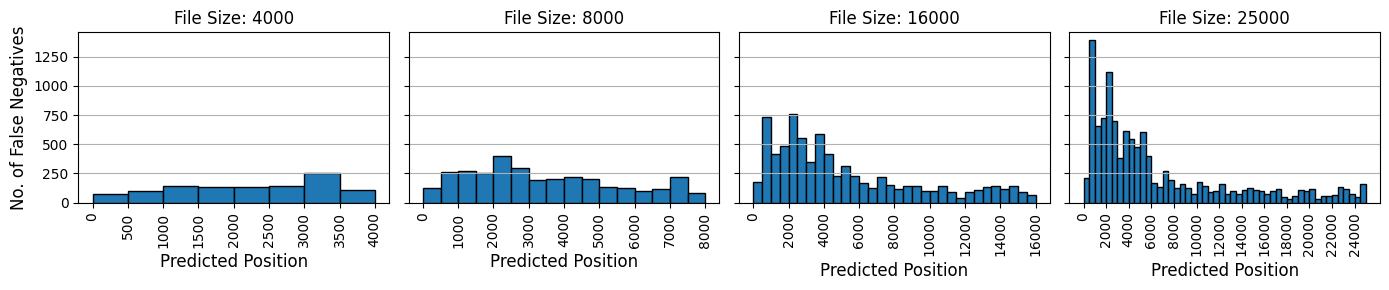

In [68]:
fontsize= 12
def plot_predicted_position_occurrences(df):
    unique_lengths = df['target_length'].unique()
    num_plots = len(unique_lengths)
    
    fig, axes = plt.subplots(nrows=1, ncols=num_plots, figsize=(14, 3), sharey=True)
    if num_plots == 1:
        axes = [axes]
    
    for ax, target_length in zip(axes, unique_lengths):
        subset = df[(df['target_length'] == target_length) & (df['bug_line_position'] != False)]
        ax.hist(subset['bug_line_position'], bins=range(0, target_length + 500, 500), edgecolor='black')
        ax.set_xlabel('Predicted Position', fontsize=fontsize)
        ax.set_title(f'File Size: {target_length}', fontsize=fontsize)
        
        xticks = range(0, target_length + 500, 500)
        if len(xticks) > 30:  # Adjust xticks if there are too many
            xticks = xticks[::4]  # Take every other xtick
        elif len(xticks) > 10:  # Adjust xticks if there are too many
            xticks = xticks[::2]  # Take every other xtick
        
        ax.set_xticks(xticks)
        ax.tick_params(axis='x', rotation=90, labelsize=10)
        ax.grid(axis='y')
    
    axes[0].set_ylabel('No. of False Negatives', fontsize=fontsize)  # Set Y label only for the first subplot
    
    plt.tight_layout()
    plt.savefig("./false_negatives_predicted_position_distribution.pdf")
    plt.show()

    plt.show()
# another visualisation possibilities
# for CWe in CWEs in df unique
# for cwe in df['CWE_ID'].unique():
#     print(f"Plotting predicted position occurrences for {cwe}")
#     # filter out FN
#     df_sub = df[(df['CWE_ID'] == cwe) & (df['classification'] == 'FN')]
#     plot_predicted_position_occurrences(df_sub)

# # for uniwue models
# for model in df['model'].unique():
#     print(f"Plotting predicted position occurrences for {model}")
#     # filter out FN
#     df_sub = df[(df['model'] == model) & (df['classification'] == 'FN')]
#     plot_predicted_position_occurrences(df_sub)

plot_predicted_position_occurrences(df_total[df_total['classification'] == 'FN'])